# House Prices - Advanced Regression Techniques


### importing libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. Data Retrieval
1. Data Retrieval

• Loading: Use pandas to read both train.csv and test.csv into separate DataFrames.

• Dataset Inspection: Print the dimensions (shape) of both datasets and display the first five
rows of the training set to verify the column structure.

• Memory Management: Identify column data types and demonstrate how to load the data
using specific dtype parameters to optimize memory usage (e.g., downcasting floats or using
category for categorical strings).

In [42]:
# Data Loading 
train_data= pd.read_csv("data/train.csv")
test_data= pd.read_csv("data/test.csv")


In [4]:
# shape of the dataset 
print("train data ", train_data.shape)
print("test data ", test_data.shape)


train data  (1460, 81)
test data  (1459, 80)


In [5]:
# show the first rows to understand the data 
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# checking the data types and missing values
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
# get memory usage of the dataset
mem_before = train_data.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage before optimization: {mem_before:.2f} MB")

#  deep = true ; to get the actual memory usage of the dataset, including the memory used by the objects in the dataset.

Memory usage before optimization: 3.43 MB


In [8]:
# analysis cols types 
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train_data.select_dtypes(include=['object']).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 38
Categorical columns: 43


In [ ]:
# down casting string columns to category type to reduce memory usage
for col in cat_cols:
    train_data[col] = train_data[col].astype('category')

In [ ]:
# Downcasting numerical columns to reduce memory usage
for col in num_cols:
    train_data[col] = pd.to_numeric(train_data[col], downcast='float')

In [12]:
mem_after = train_data.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before: {mem_before:.2f} MB")
print(f"Memory after: {mem_after:.2f} MB")

Memory before: 3.43 MB
Memory after: 0.29 MB


### Memory Optimization

We optimized memory usage by:
- Downcasting numerical columns to more efficient types (e.g., float32 instead of float64)
- Converting categorical string columns into pandas 'category' dtype

This significantly reduces memory usage and improves computational efficiency.
Memory before: 3.43 MB
Memory after: 0.29 MB


In [19]:
# Drop ID
train_data.drop("Id", axis=1, inplace=True)
test_data.drop("Id", axis=1, inplace=True)

# Fix MSSubClass
train_data["MSSubClass"] = train_data["MSSubClass"].astype("category")
test_data["MSSubClass"] = test_data["MSSubClass"].astype("category")

KeyError: "['Id'] not found in axis"

In [20]:
# checking the data types and missing values after optimization
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   category
 1   MSZoning       1460 non-null   category
 2   LotFrontage    1201 non-null   float32 
 3   LotArea        1460 non-null   float32 
 4   Street         1460 non-null   category
 5   Alley          91 non-null     category
 6   LotShape       1460 non-null   category
 7   LandContour    1460 non-null   category
 8   Utilities      1460 non-null   category
 9   LotConfig      1460 non-null   category
 10  LandSlope      1460 non-null   category
 11  Neighborhood   1460 non-null   category
 12  Condition1     1460 non-null   category
 13  Condition2     1460 non-null   category
 14  BldgType       1460 non-null   category
 15  HouseStyle     1460 non-null   category
 16  OverallQual    1460 non-null   float32 
 17  OverallCond    1460 non-null   fl

# 2. Data Cleaning
* Missing Value Analysis: Identify columns with significant missing values. For features like
PoolQC, MiscFeature, Alley, and Fence, determine if "NaN" represents a missing value or a
specific category (e.g., "No Pool"). Apply appropriate fill strategies.

* Outlier Removal: Plot the distribution of the target variable SalePrice. Identify observations
that act as significant outliers (e.g., houses with extreme ground living area) and justify
whether they should be removed to improve model training.
* Data Transformation: The SalePrice distribution is right-skewed. 
Apply a logarithmic transformation (np.log1p) to normalize the target variable.

 **Missing Value Analysis**: 
 
 Identify columns with significant missing values. 
 
 For features like : PoolQC, MiscFeature, Alley, and Fence,
 
  determine if "NaN" represents a missing value or a specific category (e.g., "No Pool"). 
  
  Apply appropriate fill strategies.

In [22]:
# check missing values
missing = train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [23]:
#  Calculate missing value percentages
missing_percent = (missing / len(train_data)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [50]:
def handle_missing(df):
    
    # 1. Columns where missing means "feature does not exist"
    cols_to_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                    'MasVnrType']
    
    for col in cols_to_none:
        if df[col].dtype.name == "category":
            df[col] = df[col].cat.add_categories('None')
        df[col] = df[col].fillna('None')

    # 2. LotFrontage (group-based + fallback)
    df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"]\
                          .transform(lambda x: x.fillna(x.median()))
    
    df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

    # 3. Numeric "no feature"
    for col in ['GarageYrBlt', 'MasVnrArea']:
        df[col] = df[col].fillna(0)

    # 4. Small missing → mode
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

    return df

In [51]:
# handle missing values 
train_data = handle_missing(train_data)
test_data = handle_missing(test_data)

In [ ]:
# final check 
print("Train missing:", train_data.isnull().sum().sum())
print("Test missing:", test_data.isnull().sum().sum())

Train missing: 0
Test missing: 22


**Outlier Removal**: 
- Plot the distribution of the target variable SalePrice. 
- Identify observations that act as significant outliers (e.g., houses with extreme ground living area) and justify whether they should be removed to improve model training.

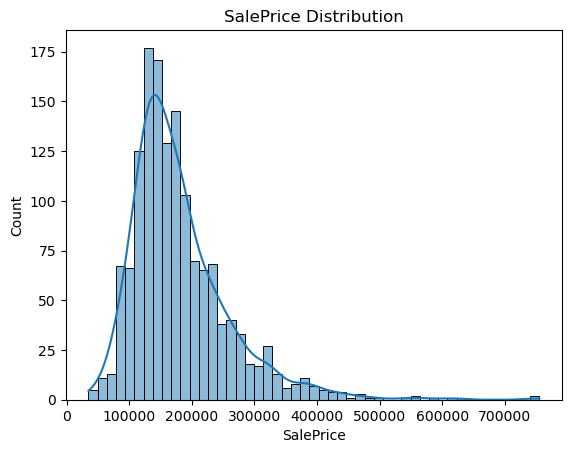

In [ ]:
# salasprice distribution
sns.histplot(train_data["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

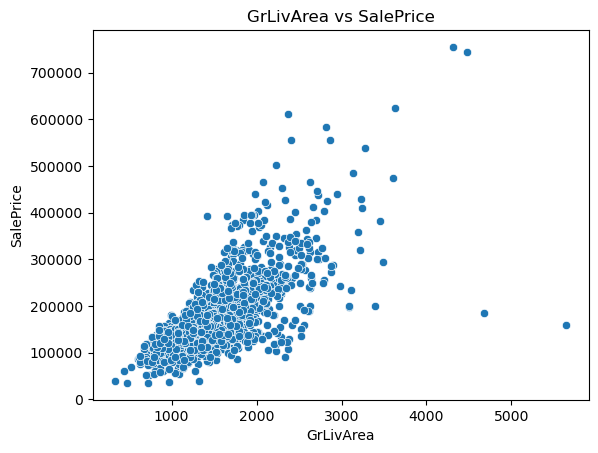

In [54]:
sns.scatterplot(x=train_data["GrLivArea"], y=train_data["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

In [55]:
# based on the previous plot, we can see that there are some outliers with large GrLivArea and low SalePrice. We will remove those outliers to improve model training.
train_data = train_data.drop(train_data[((train_data["GrLivArea"] > 4000) & (train_data["SalePrice"] < 300000))].index)

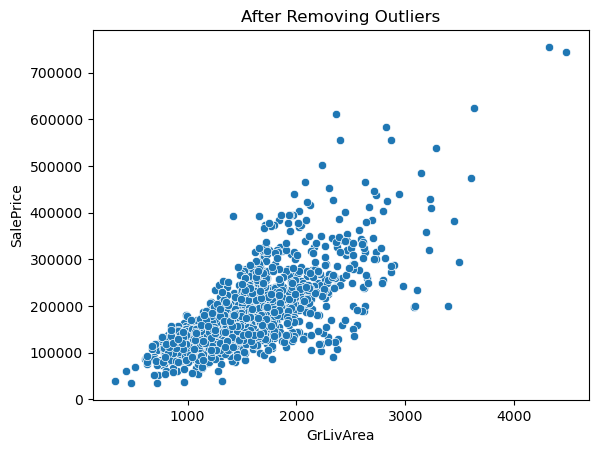

In [ ]:
# repolt the distubution after reomove the outliers 
sns.scatterplot(x=train_data['GrLivArea'], y=train_data['SalePrice'])
plt.title("After Removing Outliers")
plt.show()

#  everything look good 

**Data Transformation** : 
- The SalePrice distribution is right-skewed. 
- Apply a logarithmic transformation (np.log1p) to normalize the target variable.

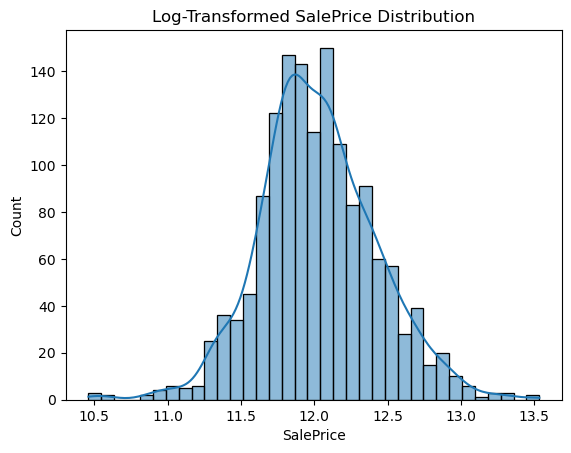

In [57]:
# convert the SalePrice to log scale for normal distribution 
train_data["SalePrice"] = np.log1p(train_data["SalePrice"])

# the plot with log scale 
sns.histplot(train_data["SalePrice"], kde=True)
plt.title("Log-Transformed SalePrice Distribution")
plt.show()

# 3. Exploratory Data Analysis (EDA)

* Correlation Analysis: 

  Compute a correlation matrix for numerical features. Use a heatmap to identify the top 5 features most strongly correlated with SalePrice.

*  Visual Exploration: 

     Create a scatter plot showing the relationship between GrLivArea (Above grade (ground) living area square feet) and SalePrice, colored by OverallQual.

* Geographical Insights: 

  Use plotly.express or seaborn to visualize the average SalePrice across different Neighborhood values.

 **Correlation Analysis:** 

  Compute a correlation matrix for numerical features. Use a heatmap to identify the top 5 features most strongly correlated with SalePrice.


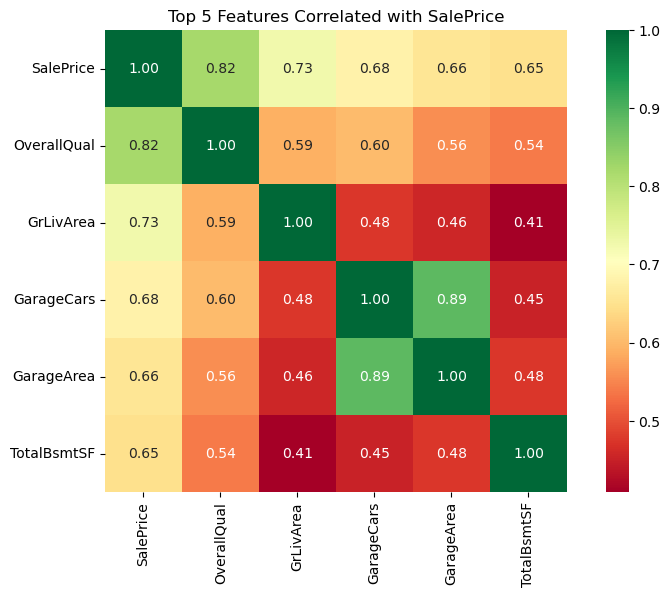

Top 5 correlated features with SalePrice:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


In [60]:
#  correlation analysis fro numberical features 
corr_mat = train_data.corr(numeric_only=True)
# the top 5 features correlcted with SalePrice
top_corr_features = corr_mat.nlargest(6, 'SalePrice')['SalePrice'].index
# plot the heatmap for top 5 features 
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[top_corr_features].corr(), annot=True, cmap='RdYlGn', square=True, fmt='.2f')
plt.title('Top 5 Features Correlated with SalePrice')
plt.show()
#print the top 5 features 
print("Top 5 correlated features with SalePrice:")
print(top_corr_features[1:].tolist())

# Annotation :annot 

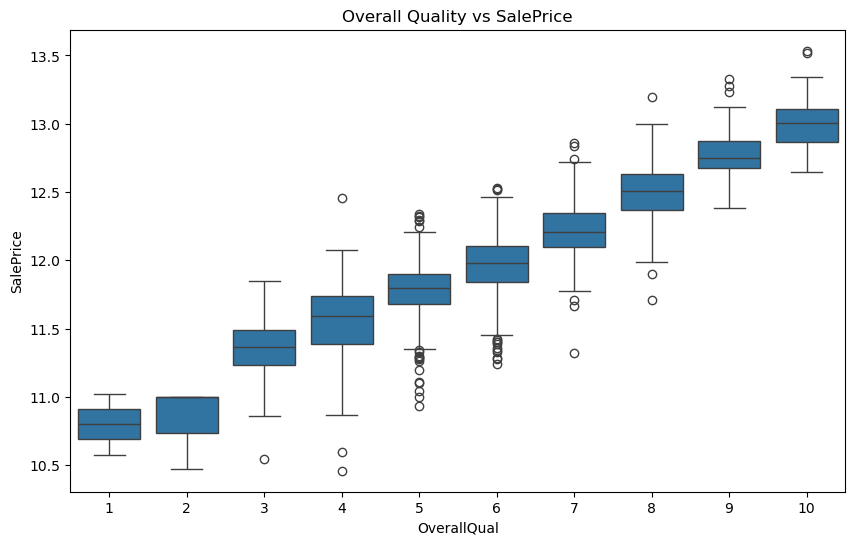

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train_data)
plt.title('Overall Quality vs SalePrice')
plt.show()

# Drawing the relationship between overall quality and selling price
# We observe a clear direct relationship; the higher the quality, the higher the price.

**Visual Exploration:** 

Create a scatter plot showing the relationship between GrLivArea (Above grade (ground) living area square feet) and SalePrice, colored by OverallQual.


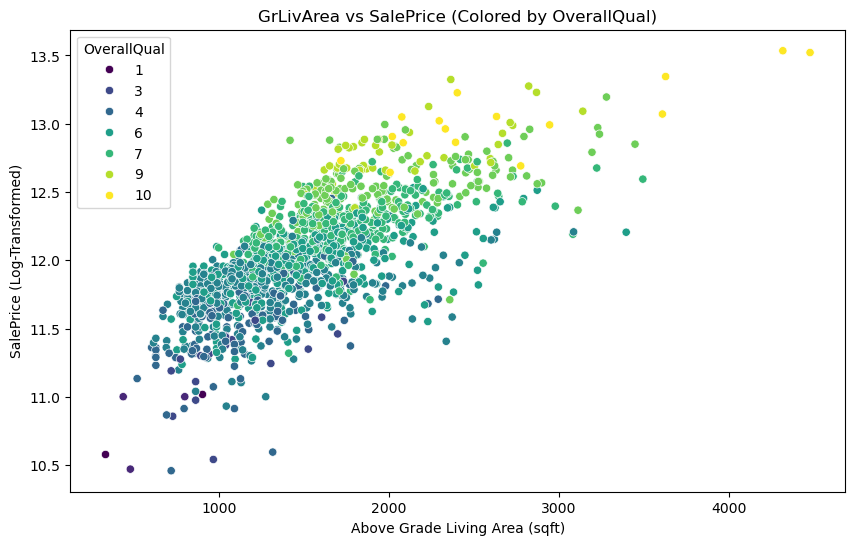

In [62]:
# visualize the relationship between GrLivArea and SalePrice, colored by OverallQual
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='OverallQual', data=train_data, palette='viridis')
plt.title('GrLivArea vs SalePrice (Colored by OverallQual)')
plt.xlabel('Above Grade Living Area (sqft)')
plt.ylabel('SalePrice (Log-Transformed)')
plt.show()

Scatter plot of GrLivArea vs SalePrice, color-coded by OverallQual
1. Linear Trend: Clear positive correlation between living area and sale price.
2. Quality Impact: For the same square footage, higher quality homes (lighter dots) consistently command a price premium.
3. Homoscedasticity: The log-transformation of SalePrice ensures a stable variance across the entire range of living area.

**Geographical Insights:**

  Use plotly.express or seaborn to visualize the average SalePrice across different Neighborhood values.

C:\Users\pc home\AppData\Local\Temp\ipykernel_28252\2704607816.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SalePrice', y='Neighborhood', data=train_data,


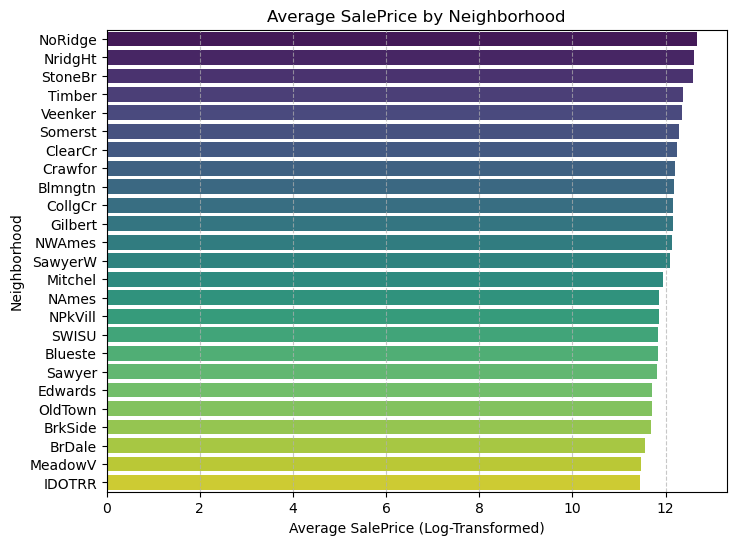

In [64]:
#  Calculate the average selling price for each neighborhood and rank them in descending order.
neighborhood_order = train_data.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).index

# plot the average price for each neighborhood 
plt.figure(figsize=(8, 6))
sns.barplot(x='SalePrice', y='Neighborhood', data=train_data, 
            order=neighborhood_order, palette='viridis', errorbar=None)


plt.title('Average SalePrice by Neighborhood')
plt.xlabel('Average SalePrice (Log-Transformed)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

We observe a clear and regular gradation in colors and lengths; this means that "neighborhood" is not just descriptive information, but a crucial factor reflecting the quality of services, safety, and demand in each area.

# 4. Feature Engineering
* Feature Transformation: 

Create a new feature TotalSF by summing TotalBsmtSF, 1stFlrSF, and 2ndFlrSF.
 
* Encoding Categorical Variables:

     For ordinal features (e.g., ExterQual, KitchenQual), apply Label Encoding to preserve the ranking.
     
     For nominal features (e.g., Neighborhood, BldgType), apply One-Hot Encoding.

*  Pipeline Construction: 

  Combine the cleaning and transformation steps into a reusable function or scikit-learn Pipeline object so that the same operations are applied consistently to both the training and testing sets.